<h1 style="text-align: center; color: darkblue;">EDA and Quick Prototyping</h1>

### 📑 <font color='blue'> Table of Contents </font>
1. [Introduction](#1)
2. [Setup](#2)
3. [Load best run and artifacs](#3)
4. [Results and visualization](#4)
5. [Inference](#5)

## <a id="1" style="color: darkred; text-decoration: none;">1. Introduction</a>

In this notebook, we explore Industrial Control System (ICS) network traffic data with the goal of understanding its structure and behavior. We’ll perform Exploratory Data Analysis (EDA) to identify key patterns, relationships, and potential challenges within the dataset — such as class imbalance or feature correlations.

After gaining insights from the data, we’ll move into quick prototyping by training a few simple supervised models to classify network traffic into categories such as benign, DoS, DoS Hulk, and others.

The objective here is not to build the most accurate model, but to:

- Develop an initial understanding of the data.

- Identify which features or preprocessing steps might be useful.

- Evaluate baseline models to guide future, more sophisticated experiments.

This notebook serves as a foundation for deeper modeling and optimization later in the pipeline.

## <a id="2" style="color: darkred; text-decoration: none;"> 2.Setup </a>

In [58]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

## <a id="3" style="color: darkred; text-decoration: none;"> 3.Helper Functions </a>

## <a id="2" style="color: darkred; text-decoration: none;"> 4. Loading and inspecting data </a>

Given the restricted resources and the fact that this is a portfolio project, I will use a subset of the ICS Dataset

--> credits to author


Dataset Acknowledgement
This work uses the CIC-IDS2017 dataset made available by the Canadian Institute for Cybersecurity at the University of New Brunswick.
Please cite: Sharafaldin I., Lashkari A.H., Ghorbani A.A. (2018) “Toward Generating a New Intrusion Detection Dataset and Intrusion Traffic Characterization”. ICISSP.


Sharafaldin I., Lashkari A. H., & Ghorbani A. A. (2018). Toward Generating a New Intrusion Detection Dataset and Intrusion Traffic Characterization. In 4th International Conference on Information Systems Security and Privacy (ICISSP). University of New Brunswick, Canadian Institute for Cybersecurity. Dataset: CIC-IDS2017. Available at: https://www.unb.ca/cic/datasets/ids-2017.html



https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset


OFFICIAL!!!!


The CICIDS2017 dataset consists of labeled network flows, including full packet payloads in pcap format, the corresponding profiles and the labeled flows (GeneratedLabelledFlows.zip) and CSV files for machine and deep learning purpose (MachineLearningCSV.zip) are publicly available for researchers. If you are using our dataset, you should cite our related paper which outlining the details of the dataset and its underlying principles:

Iman Sharafaldin, Arash Habibi Lashkari, and Ali A. Ghorbani, “Toward Generating a New Intrusion Detection Dataset and Intrusion Traffic Characterization”, 4th International Conference on Information Systems Security and Privacy (ICISSP), Portugal, January 2018.

------------------------------


In [7]:
df = pd.read_csv("../data/data.csv", encoding="latin1")
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,61900,54,2,2,4,12,2,2,2.000000,0.000000,...,24,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,24800,49,2,0,4,0,2,2,2.000000,0.000000,...,24,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,443,5885346,9,6,710,3826,517,0,78.888889,172.656773,...,32,292949.0,0.0,292949,292949,5592381.0,0.0,5592381,5592381,BENIGN
3,49738,57,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,80,98306933,6,7,363,11595,345,0,60.500000,139.406958,...,20,14018.0,0.0,14018,14018,98300000.0,0.0,98300000,98300000,DoS Hulk


In [ ]:
# COPY OF THE DATA

In [92]:
"""

# Load raw data
df = pd.read_csv("../data/data.csv", encoding="latin1")

# Make a working copy for transformations
data = df.copy()

# Perform cleaning/preprocessing
data = data.dropna()
data = data[data["age"] > 18]

# Now `data` is your cleaned version,
# and `df` remains the raw, original dataset.


"""


'\n\n# Load raw data\ndf = pd.read_csv("../data/data.csv", encoding="latin1")\n\n# Make a working copy for transformations\ndata = df.copy()\n\n# Perform cleaning/preprocessing\ndata = data.dropna()\ndata = data[data["age"] > 18]\n\n# Now `data` is your cleaned version,\n# and `df` remains the raw, original dataset.\n\n\n'

Data Integritu¿y check


| Check              | What it tells you                              | Example code                    |
| ------------------ | ---------------------------------------------- | ------------------------------- |
| **Shape**          | Confirms expected number of rows/columns       | `df.shape`                      |
| **Missing values** | Detects incomplete data                        | `df.isna().sum()`               |
| **Duplicates**     | Ensures no repeated rows                       | `df.duplicated().sum()`         |
| **Column types**   | Confirms correct dtypes (numeric, categorical) | `df.dtypes`                     |
| **Unique values**  | Detects anomalies in categorical vars          | `df['category'].value_counts()` |
| **Basic stats**    | Checks distributions, outliers                 | `df.describe(include='all')`    |


In [94]:
import pandas as pd

pd.set_option("display.max_rows", None)       # show all rows
pd.set_option("display.max_columns", None)    # show all columns
pd.set_option("display.width", None)          # don't wrap lines
pd.set_option("display.max_colwidth", None)   # show full cell content


summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isna().sum(),
    "unique": df.nunique(),
})
summary


,dtype,missing,unique
Destination Port,int64,0,10815
Flow Duration,int64,0,44161
Total Fwd Packets,int64,0,286
Total Backward Packets,int64,0,339
Total Length of Fwd Packets,int64,0,3823
Total Length of Bwd Packets,int64,0,7091
Fwd Packet Length Max,int64,0,1951
Fwd Packet Length Min,int64,0,152
Fwd Packet Length Mean,float64,0,8630
Fwd Packet Length Std,float64,0,12967


In [97]:
# columsn adn its types
df.dtypes

Destination Port                 int64
Flow Duration                    int64
Total Fwd Packets                int64
Total Backward Packets           int64
Total Length of Fwd Packets      int64
Total Length of Bwd Packets      int64
Fwd Packet Length Max            int64
Fwd Packet Length Min            int64
Fwd Packet Length Mean         float64
Fwd Packet Length Std          float64
Bwd Packet Length Max            int64
Bwd Packet Length Min            int64
Bwd Packet Length Mean         float64
Bwd Packet Length Std          float64
Flow Bytes/s                   float64
Flow Packets/s                 float64
Flow IAT Mean                  float64
Flow IAT Std                   float64
Flow IAT Max                     int64
Flow IAT Min                     int64
Fwd IAT Total                    int64
Fwd IAT Mean                   float64
Fwd IAT Std                    float64
Fwd IAT Max                      int64
Fwd IAT Min                      int64
Bwd IAT Total            

In [9]:
df.shape

(79998, 79)

In [39]:
#df.describe

In [12]:
df.duplicated().sum()

2649

In [14]:
# drop duplicates
df = df.drop_duplicates()
df = df.dropna()

In [15]:
df.duplicated().sum()

0

In [21]:
# handle infinities
np.isinf(df.select_dtypes(include=[np.number])).any().any()

True

In [22]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.dropna()

np.isinf(df.select_dtypes(include=[np.number])).any().any()

False

In [35]:
# missing values (NaN, None)
# Count NaNs per column
print(df.isna().sum())

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
Idle Std                       0
Idle Max                       0
Idle Min                       0
Label                          0
Length: 79, dtype: int64


In [36]:
df.shape

(77305, 79)

In [37]:
# we have no mjssing values but if i had i can use:
# Drop columns where >50% values are missing
threshold = 0.5
df = df.loc[:, df.isna().mean() < threshold]

In [32]:
# label distribution

# Count rows per class
label_counts = df['Label'].value_counts()
print("\033[1mLabel counts\n\033[0m\n", label_counts)


print("--------------------------------------\n")

# Percentage of each class
label_percent = df['Label'].value_counts(normalize=True) * 100
print("\033[1mLabel counts (%)\n\033[0m\n", label_percent)

Label counts

 BENIGN                        63101
DoS Hulk                       5162
PortScan                       4373
DDoS                           3618
DoS GoldenEye                   291
FTP-Patator                     189
DoS slowloris                   162
DoS Slowhttptest                155
SSH-Patator                     138
Bot                              54
Web Attack ï¿½ Brute Force       43
Web Attack ï¿½ XSS               19
Name: Label, dtype: int64
--------------------------------------

Label counts (%)

 BENIGN                        81.626027
DoS Hulk                       6.677446
PortScan                       5.656814
DDoS                           4.680163
DoS GoldenEye                  0.376431
FTP-Patator                    0.244486
DoS slowloris                  0.209560
DoS Slowhttptest               0.200504
SSH-Patator                    0.178514
Bot                            0.069853
Web Attack ï¿½ Brute Force     0.055624
Web Attack ï¿½ XSS          

...........imbalance analysis

In [41]:
# combine rare attacks

# Define rare attacks to combine
rare_attacks = ['Bot', 'Web Attack � Brute Force', 'Web Attack � XSS']

# Create a new column or overwrite Label
df['Label'] = df['Label'].apply(lambda x: 'Other_Attack' if x in rare_attacks else x)

# Check the new class distribution
print(df['Label'].value_counts())
#label_percent = df['Label'].value_counts(normalize=True) * 100

BENIGN                        63101
DoS Hulk                       5162
PortScan                       4373
DDoS                           3618
DoS GoldenEye                   291
FTP-Patator                     189
DoS slowloris                   162
DoS Slowhttptest                155
SSH-Patator                     138
Other_Attack                     54
Web Attack ï¿½ Brute Force       43
Web Attack ï¿½ XSS               19
Name: Label, dtype: int64


In [ ]:
"""
keep only relevant features

# List of features to keep
keep_features = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std',
    'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std',
    'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
    'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
    'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min',
    'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count',
    'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags',
    'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'Down/Up Ratio', 'Average Packet Size',
    'Label'  # Keep the target
]

# Strip column names first to avoid mismatch -> i did it before
df_sample.columns = df_sample.columns.str.strip()

# Keep only the selected columns
df_clean = df_sample[keep_features].copy()

# Optional: check the shape
print("Cleaned DataFrame shape:", df_clean.shape)

# Optional: check class balance
print(df_clean['Label'].value_counts())


"""

In [44]:
# label encodign
# Create encoder
le = LabelEncoder()

# Fit and transform the Label column
df['Label'] = le.fit_transform(df['Label'])

# Optional: see the mapping of classes
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label mapping:", label_mapping)

# Check the new class distribution
print(df['Label'].value_counts())

Label mapping: {'BENIGN': 0, 'DDoS': 1, 'DoS GoldenEye': 2, 'DoS Hulk': 3, 'DoS Slowhttptest': 4, 'DoS slowloris': 5, 'FTP-Patator': 6, 'Other_Attack': 7, 'PortScan': 8, 'SSH-Patator': 9, 'Web Attack ï¿½ Brute Force': 10, 'Web Attack ï¿½ XSS': 11}
0     63101
3      5162
8      4373
1      3618
2       291
6       189
5       162
4       155
9       138
7        54
10       43
11       19
Name: Label, dtype: int64


In [54]:
# separe features and labels
# X = features, y = target
X = df.drop('Label', axis=1)
y = df['Label']


y[0:3]

/tmp/ipykernel_295168/1715984069.py:7: FutureWarning: The behavior of `series[i:j]` with an integer-dtype index is deprecated. In a future version, this will be treated as *label-based* indexing, consistent with e.g. `series[i]` lookups. To retain the old behavior, use `series.iloc[i:j]`. To get the future behavior, use `series.loc[i:j]`.
  y[0:3]


0    0
1    0
2    0
Name: Label, dtype: int64

In [56]:
# train/val split
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,      # preserves class distribution
    random_state=42
)

print("Train/Val shape:", X_train_val.shape)
print("Test shape:", X_test.shape)

Train/Val shape: (61844, 78)
Test shape: (15461, 78)


In [60]:
# -----------------------------
# 3️⃣ Apply SMOTE only for minority classes
# -----------------------------
# For example, let's upsample classes with < 2000 samples
minority_classes = y_train.value_counts()[y_train.value_counts() < 2000].index.tolist()
sampling_dict = {cls: 2000 for cls in minority_classes}  # generate 2000 samples per rare class

smote = SMOTE(sampling_strategy=sampling_dict, random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

print("Class counts after SMOTE:")
print(pd.Series(y_res).value_counts())

Class counts after SMOTE:
0     50481
3      4130
8      3498
1      2895
9      2000
4      2000
6      2000
7      2000
10     2000
5      2000
2      2000
11     2000
Name: Label, dtype: int64


In [61]:
# neural nets needs scaling
# -----------------------------
# 2️⃣ Scale features
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [ ]:
# combine verything in one function

## <a id="5" style="color: darkred; text-decoration: none;"> 5. Models </a>


### <a id="5.1" style="color: darkorange; text-decoration: none;"> 5.1. Baseline </a>


lr for multilcass data................

In [64]:
# baseline
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000, multi_class='multinomial', solver='lbfgs')
lr.fit(X_train_scaled, y_train)
y_val_pred = lr.predict(X_val_scaled)
print(classification_report(y_val, y_val_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     12620
           1       0.98      0.98      0.98       723
           2       0.96      0.81      0.88        58
           3       0.99      0.89      0.94      1032
           4       0.81      0.71      0.76        31
           5       0.96      0.78      0.86        32
           6       0.90      0.50      0.64        38
           7       0.00      0.00      0.00        11
           8       0.81      0.99      0.89       875
           9       0.00      0.00      0.00        28
          10       0.00      0.00      0.00         9
          11       0.00      0.00      0.00         4

    accuracy                           0.97     15461
   macro avg       0.62      0.55      0.58     15461
weighted avg       0.97      0.97      0.97     15461



In [65]:
# good f1-score exccpet for the rare classes

### <a id="5.2" style="color: darkorange; text-decoration: none;"> 5.2. Tree </a>

In [69]:
from sklearn.tree import DecisionTreeClassifier

# Create and train tree model
tree = DecisionTreeClassifier(
    criterion='gini',  # or 'entropy'
    max_depth=10,      # limit depth to avoid overfitting
    random_state=42
)
tree.fit(X_train, y_train)

# Evaluate
y_pred = tree.predict(X_val)

print(confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred, digits=3, zero_division=0))

#zero_division=0 avoids warnings for classes with no predicted samples.
#If your dataset is imbalanced, you may consider adding class_weight='balanced':

[[12601     1     0    12     0     1     1     0     4     0     0     0]
 [    2   718     0     3     0     0     0     0     0     0     0     0]
 [    8     0    50     0     0     0     0     0     0     0     0     0]
 [    3     0     1  1028     0     0     0     0     0     0     0     0]
 [    9     0     1     0    21     0     0     0     0     0     0     0]
 [    1     0     0     0     0    31     0     0     0     0     0     0]
 [    0     0     0     0     0     0    38     0     0     0     0     0]
 [   11     0     0     0     0     0     0     0     0     0     0     0]
 [    0     0     0     0     0     0     0     0   875     0     0     0]
 [    0     0     0     1     0     0     0     0     0    27     0     0]
 [    9     0     0     0     0     0     0     0     0     0     0     0]
 [    4     0     0     0     0     0     0     0     0     0     0     0]]
              precision    recall  f1-score   support

           0      0.996     0.998     0.997 

In [70]:
# analysis

### <a id="5.3" style="color: darkorange; text-decoration: none;"> 5.3. Random Forest </a>

In [72]:
from sklearn.ensemble import RandomForestClassifier

# 1. Create the Random Forest classifier
rf = RandomForestClassifier(
    n_estimators=5,    # number of trees
    max_depth=None,      # allow trees to grow fully
    random_state=42,
    n_jobs=-1            # use all cores
)

# 2. Train the model
rf.fit(X_train, y_train)

# 3. Predict on validation set
y_val_pred = rf.predict(X_val)

# 4. Evaluate performance
print("Classification Report:\n")
print(classification_report(y_val, y_val_pred, zero_division=0))

print("Confusion Matrix:\n")
print(pd.DataFrame(confusion_matrix(y_val, y_val_pred), 
                   index=rf.classes_, columns=rf.classes_))

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12620
           1       1.00      1.00      1.00       723
           2       1.00      0.97      0.98        58
           3       0.99      0.99      0.99      1032
           4       0.97      0.94      0.95        31
           5       1.00      1.00      1.00        32
           6       1.00      1.00      1.00        38
           7       1.00      0.73      0.84        11
           8       1.00      0.99      0.99       875
           9       1.00      0.96      0.98        28
          10       0.71      0.56      0.63         9
          11       0.50      0.25      0.33         4

    accuracy                           1.00     15461
   macro avg       0.93      0.86      0.89     15461
weighted avg       1.00      1.00      1.00     15461

Confusion Matrix:

       0    1   2     3   4   5   6   7    8   9   10  11
0   12608    1   0     7   1   0

### <a id="5.4" style="color: darkorange; text-decoration: none;"> 5.4. Simple Neural Network </a>

In [73]:
# Suppose X_train, X_val, X_test are your features
scaler = StandardScaler()

# 1. Fit only on training data
scaler.fit(X_train)

# 2. Transform train, validation, and test
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)

In [74]:
# -----------------------------
# Convert data to PyTorch tensors
# -----------------------------
X_train_tensor = torch.tensor(X_train_scaled.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

X_val_tensor = torch.tensor(X_val_scaled.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [75]:
# -----------------------------
# Define a simple feedforward NN
# -----------------------------
input_size = X_train.shape[1]
num_classes = len(y_train.unique())

class SimpleNN(nn.Module):
    def __init__(self, input_size, num_classes):
        super(SimpleNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.model(x)

model = SimpleNN(input_size, num_classes)

In [77]:
import copy


# -----------------------------
# Loss and optimizer
# -----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# -----------------------------
# 4️⃣ Training loop with Early Stopping
# -----------------------------
num_epochs = 15
patience = 5  # stop if val accuracy does not improve after 5 epochs
best_val_acc = 0
epochs_no_improve = 0
best_model = copy.deepcopy(model.state_dict())

for epoch in range(num_epochs):
    model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
    
    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
    val_acc = correct / total
    print(f"Epoch {epoch+1}/{num_epochs}, Validation Accuracy: {val_acc:.4f}")
    
    # Early stopping check
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

# Load the best model
model.load_state_dict(best_model)


Epoch 1/15, Validation Accuracy: 0.9666
Epoch 2/15, Validation Accuracy: 0.9695
Epoch 3/15, Validation Accuracy: 0.9680
Epoch 4/15, Validation Accuracy: 0.9741
Epoch 5/15, Validation Accuracy: 0.9746
Epoch 6/15, Validation Accuracy: 0.9691
Epoch 7/15, Validation Accuracy: 0.9745
Epoch 8/15, Validation Accuracy: 0.9777
Epoch 9/15, Validation Accuracy: 0.9771
Epoch 10/15, Validation Accuracy: 0.9794
Epoch 11/15, Validation Accuracy: 0.9785
Epoch 12/15, Validation Accuracy: 0.9794
Epoch 13/15, Validation Accuracy: 0.9790
Epoch 14/15, Validation Accuracy: 0.9791
Epoch 15/15, Validation Accuracy: 0.9795


<All keys matched successfully>


Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     12620
           1       1.00      0.99      0.99       723
           2       0.93      0.88      0.90        58
           3       1.00      0.90      0.95      1032
           4       0.91      0.97      0.94        31
           5       0.94      1.00      0.97        32
           6       0.88      0.92      0.90        38
           7       1.00      0.64      0.78        11
           8       0.85      0.99      0.92       875
           9       1.00      0.96      0.98        28
          10       1.00      0.11      0.20         9
          11       0.00      0.00      0.00         4

    accuracy                           0.98     15461
   macro avg       0.87      0.78      0.79     15461
weighted avg       0.98      0.98      0.98     15461


Confusion Matrix:

       0    1   2    3   4   5   6   7    8   9   10  11
0   12451    2   3    4   3   2

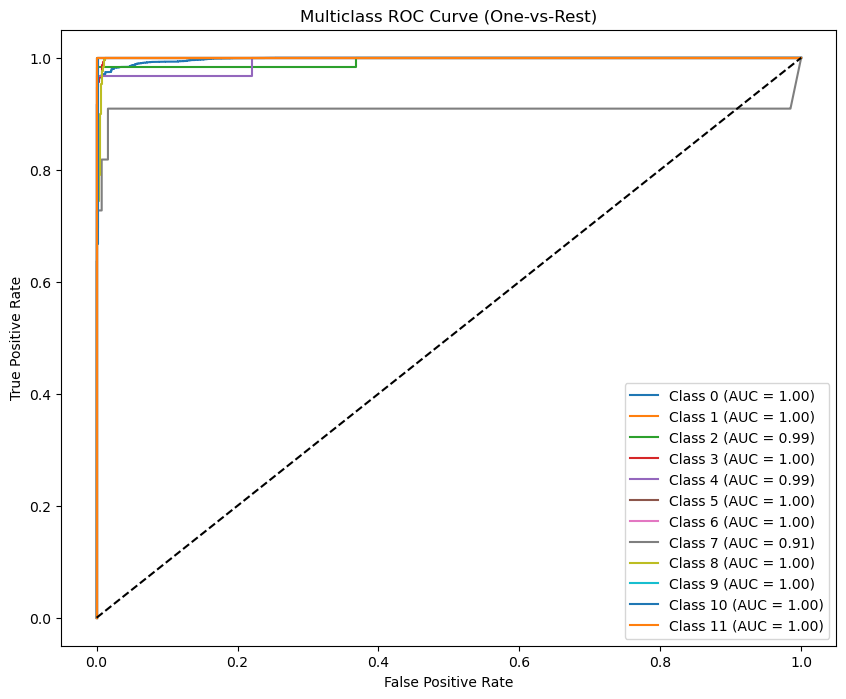

In [78]:
# -----------------------------
# 5️⃣ Evaluate on validation set
# -----------------------------
model.eval()
with torch.no_grad():
    y_val_pred_probs = model(X_val_tensor)
    y_val_pred = torch.argmax(y_val_pred_probs, 1)

y_val_true = y_val_tensor.numpy()
y_val_pred = y_val_pred.numpy()

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_val_true, y_val_pred, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_val_true, y_val_pred)
print("\nConfusion Matrix:\n")
print(pd.DataFrame(cm, index=range(num_classes), columns=range(num_classes)))

# -----------------------------
# 6️⃣ ROC curve (One-vs-Rest)
# -----------------------------
y_val_onehot = nn.functional.one_hot(y_val_tensor, num_classes=num_classes).numpy()
y_score = nn.Softmax(dim=1)(y_val_pred_probs).numpy()

plt.figure(figsize=(10,8))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_val_onehot[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve (One-vs-Rest)')
plt.legend(loc='lower right')
plt.show()

In [79]:
# analysis.................; maybe SMOTE data; use X_res (res is for resampling)

### Simple tuning

In [88]:
# tuning by val_Acc in this example
from ray import tune
from ray.tune.schedulers import ASHAScheduler


class nn_model(nn.Module):
    def __init__(self, input_size, num_classes, hidden1=128, hidden2=64, dropout=0.0):
        super(nn_model, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, num_classes)
        )

    def forward(self, x):
        return self.model(x)


def train_model(config, X_train, y_train, X_val, y_val, input_size, num_classes):
    
    
    # Ensure numpy arrays (in case user passes DataFrames)
    if hasattr(X_train, "values"):
        X_train = X_train.values
    if hasattr(y_train, "values"):
        y_train = y_train.values
    if hasattr(X_val, "values"):
        X_val = X_val.values
    if hasattr(y_val, "values"):
        y_val = y_val.values
    
    # create model
    model = nn_model(
        input_size=input_size,
        num_classes=num_classes,
        hidden1=config["hidden1"],
        hidden2=config["hidden2"],
        dropout=config["dropout"]
    )

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config["lr"])

    # Dataloaders
    train_dataset = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.long)
    )
    val_dataset = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.long)
    )

    train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

    for epoch in range(5):  # keep it small for tuning
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

        # Validation accuracy
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                _, predicted = torch.max(outputs, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()
        val_acc = correct / total

        # Report result to Ray Tune
        tune.report({"val_accuracy": val_acc})

        
#pip install ray[tune]


In [89]:
search_space = {
    "lr": tune.loguniform(1e-4, 1e-2),
    "batch_size": tune.choice([32, 64, 128]),
    "hidden1": tune.choice([64, 128, 256]),
    "hidden2": tune.choice([32, 64, 128]),
    "dropout": tune.uniform(0.0, 0.5)
}

scheduler = ASHAScheduler(metric="val_accuracy", mode="max")


input_size = X_train.shape[1]
num_classes = len(y_train.unique())


tuner = tune.Tuner(
    tune.with_resources(
        tune.with_parameters(
            train_model,
            X_train=X_train,
            y_train=y_train,
            X_val=X_val,
            y_val=y_val,
            input_size=input_size,
            num_classes=num_classes,
        ),
        resources={"cpu": 1}  # adjust for your machine
    ),
    tune_config=tune.TuneConfig(
        num_samples=5,  # number of configs to test
        scheduler=scheduler
    ),
    param_space=search_space,
)

results = tuner.fit()

best_result = results.get_best_result("val_accuracy", "max")
print("Best config:", best_result.config)
print("Best accuracy:", best_result.metrics["val_accuracy"])


2025-10-31 18:46:42,529	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/home/marcos/ray_results/train_model_2025-10-31_18-46-17' in 0.0069s.
2025-10-31 18:46:42,535	INFO tune.py:1041 -- Total run time: 25.19 seconds (25.16 seconds for the tuning loop).


Best config: {'lr': 0.0010247673997187783, 'batch_size': 32, 'hidden1': 256, 'hidden2': 32, 'dropout': 0.3303530918874518}
Best accuracy: 0.8162473319966367


### to use a custom metric in tuner

```
# custom selection

from sklearn.metrics import f1_score, recall_score

# inside train_model after validation
y_true = []
y_pred = []
with torch.no_grad():
    for xb, yb in val_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb)
        y_pred.extend(preds.argmax(dim=1).cpu().numpy())
        y_true.extend(yb.cpu().numpy())

val_f1 = f1_score(y_true, y_pred, average='macro')
val_recall = recall_score(y_true, y_pred, average='macro')

# report both metrics to Ray Tune
tune.report({"val_f1": val_f1, "val_recall": val_recall})


# results: Tuner.fit() output
all_results = results.get_dataframe()  # contains metrics and configs

# set recall threshold
recall_thresh = 0.7

# filter trials where recall >= threshold
eligible = all_results[all_results['val_recall'] >= recall_thresh]

# pick trial with highest F1 among eligible
if not eligible.empty:
    best_idx = eligible['val_f1'].idxmax()
    best_trial = eligible.loc[best_idx]
    print("✅ Best trial (recall>=0.7 & max F1):")
    print(best_trial)
else:
    print("⚠️ No trials passed the recall threshold")

    
    #https://chatgpt.com/c/68ed8683-4f7c-8326-bce0-951b4e9f3b53
```

## <a id="annex" style="color: darkred; text-decoration: none;"> Annex </a>


### <a id="A" style="color: darkorange; text-decoration: none;"> A. Class Imbalance </a>
